In [13]:
import os
import glob
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.windows import Window
from rasterio.warp import transform_bounds
from shapely.geometry import box, LineString, Point, Polygon
from PIL import Image
import fiona

# ==========================================
# CONFIGURATION
# ==========================================

BASE_DIR = os.getcwd() 
RAW_IMG_DIR = os.path.join(BASE_DIR, "raw_images", "chhattisgarh")
RAW_SHP_DIR = os.path.join(BASE_DIR, "raw_shapes", "chhattisgarh")

OUT_IMG_DIR = os.path.join(BASE_DIR, "processed_tiles", "images", "chhattisgarh")
OUT_MASK_DIR = os.path.join(BASE_DIR, "processed_tiles", "masks", "chhattisgarh")

os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)

TILE_SIZE = 512
BUFFER_ROAD = 3.0
BUFFER_UTIL = 2.0

LAYERS_CONFIG = [
    {"name": "Water_Body", "id": 1, "type": "poly"},
    {"name": "Road", "id": 2, "type": "poly"}, 
    {"name": "Road_Centre_Line", "id": 2, "type": "line"},
    {"name": "Built_Up_Area_type", "id": 3, "filter": {"col": "Roof_type", "val": 1}},
    {"name": "Built_Up_Area_type", "id": 4, "filter": {"col": "Roof_type", "val": 2}},
    {"name": "Built_Up_Area_type", "id": 5, "filter": {"col": "Roof_type", "val": 3}},
    {"name": "Built_Up_Area_type", "id": 6, "filter": {"col": "Roof_type", "val": 4}},
    {"name": "Utility", "id": 7, "type": "point"},
    {"name": "Utility_Poly", "id": 7, "type": "poly"}
]

# ==========================================
# ROBUST HELPER FUNCTIONS
# ==========================================

def find_shapefile(name_stub):
    candidates = glob.glob(os.path.join(RAW_SHP_DIR, f"{name_stub}.shp"))
    if not candidates:
        all_shps = glob.glob(os.path.join(RAW_SHP_DIR, "*.shp"))
        candidates = [s for s in all_shps if name_stub.lower() in os.path.basename(s).lower()]
    return candidates[0] if candidates else None

def load_and_prep_shapes(img_bounds, img_crs):
    """
    Robust loader that handles CRS mismatch between Image and Shapefile.
    """
    prepared_layers = []
    
    for layer_cfg in LAYERS_CONFIG:
        shp_path = find_shapefile(layer_cfg["name"])
        if not shp_path:
            continue
            
        # 1. Check Shapefile CRS without reading the whole file
        with fiona.open(shp_path) as src:
            shp_crs = src.crs
        
        # 2. Transform Image Bounds to Shapefile CRS
        # This fixes the "0 tiles" bug where boxes didn't overlap
        try:
            left, bottom, right, top = img_bounds
            reprojected_bbox = transform_bounds(img_crs, shp_crs, left, bottom, right, top)
        except Exception:
            # Fallback if CRS is missing, try raw bounds
            reprojected_bbox = img_bounds

        # 3. Read only intersecting features
        try:
            gdf = gpd.read_file(shp_path, bbox=reprojected_bbox)
        except:
            # If bbox fails, read all (slower but safer)
            gdf = gpd.read_file(shp_path)
            
        if gdf.empty:
            continue

        # 4. Convert to Image CRS (Meters) for processing
        if gdf.crs != img_crs:
            gdf = gdf.to_crs(img_crs)
            
        # 5. Filter Attributes (Roof Type)
        if "filter" in layer_cfg:
            col = layer_cfg["filter"]["col"]
            val = layer_cfg["filter"]["val"]
            if col in gdf.columns:
                gdf = gdf[gdf[col] == val]
            else:
                continue 
        
        if not gdf.empty:
            prepared_layers.append({
                "gdf": gdf,
                "id": layer_cfg["id"],
                "type": layer_cfg.get("type", "poly"),
                "name": layer_cfg["name"] # For debug
            })
            
    return prepared_layers

def process_village(tiff_path):
    filename = os.path.basename(tiff_path)
    village_name = os.path.splitext(filename)[0]
    
    print(f"\nProcessing: {village_name}")
    
    with rasterio.open(tiff_path) as src:
        H, W = src.height, src.width
        img_crs = src.crs
        img_bounds = src.bounds
        
        print(f"  [Info] Image Size: {W}x{H}")
        print(f"  [Info] Image CRS: {img_crs}")

        # LOAD SHAPES
        layers = load_and_prep_shapes(img_bounds, img_crs)
        
        # DEBUG: Print what we found
        total_features = sum([len(l['gdf']) for l in layers])
        print(f"  [Debug] Features found in overlap: {total_features}")
        for l in layers:
            print(f"    - {l['name']} (ID {l['id']}): {len(l['gdf'])} features")
            
        if total_features == 0:
            print("  [Warning] NO features found matching this image. Skipping tiling.")
            return 0

        # TILING LOOP
        saved_count = 0
        print(f"  [Action] Starting Tiling...")
        
        for y in range(0, H, TILE_SIZE):
            for x in range(0, W, TILE_SIZE):
                window_w = min(TILE_SIZE, W - x)
                window_h = min(TILE_SIZE, H - y)
                window = Window(x, y, window_w, window_h)
                win_bounds = src.window_bounds(window)
                win_box = box(*win_bounds)
                
                mask_arr = np.zeros((window_h, window_w), dtype=np.uint8)
                
                # Check for feature intersection
                has_data = False
                for layer in layers:
                    gdf = layer["gdf"]
                    # Quick spatial filter
                    possible = gdf.iloc[list(gdf.sindex.intersection(win_bounds))]
                    if possible.empty: continue
                    
                    precise = possible[possible.intersects(win_box)]
                    if precise.empty: continue
                    
                    # If we find actual features, we proceed
                    shapes_to_burn = []
                    for _, row in precise.iterrows():
                        geom = row.geometry
                        if layer["type"] == "line" or geom.geom_type == 'LineString':
                             geom = geom.buffer(BUFFER_ROAD)
                        elif layer["type"] == "point" or geom.geom_type == 'Point':
                             geom = geom.buffer(BUFFER_UTIL)
                        
                        clipped = geom.intersection(win_box)
                        if not clipped.is_empty:
                            shapes_to_burn.append((clipped, layer["id"]))
                    
                    if shapes_to_burn:
                        # Transform to window coordinates for rasterization
                        win_transform = src.window_transform(window)
                        layer_mask = rasterize(
                            shapes_to_burn,
                            out_shape=(window_h, window_w),
                            transform=win_transform,
                            fill=0,
                            dtype=np.uint8
                        )
                        mask_arr = np.maximum(mask_arr, layer_mask)
                        has_data = True

                # ONLY SAVE IF MASK IS NOT EMPTY
                if has_data and mask_arr.max() > 0:
                    img_arr = src.read(window=window)
                    
                    # Pad if needed
                    if window_w < TILE_SIZE or window_h < TILE_SIZE:
                        padded_img = np.zeros((3, TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                        padded_img[:, :window_h, :window_w] = img_arr
                        img_arr = padded_img
                        
                        padded_mask = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                        padded_mask[:window_h, :window_w] = mask_arr
                        mask_arr = padded_mask
                    
                    # Save
                    tile_id = f"{saved_count:05d}"
                    Image.fromarray(np.moveaxis(img_arr, 0, -1)).save(os.path.join(OUT_IMG_DIR, f"{village_name}_{tile_id}.png"))
                    Image.fromarray(mask_arr).save(os.path.join(OUT_MASK_DIR, f"{village_name}_{tile_id}_mask.png"))
                    saved_count += 1
                    
        print(f"  -> Finished. Generated {saved_count} tiles.")
        return saved_count

# ==========================================
# EXECUTION
# ==========================================
print("Looking for images...")
tiff_files = glob.glob(os.path.join(RAW_IMG_DIR, "*.tif")) + glob.glob(os.path.join(RAW_IMG_DIR, "*.TIF"))

for tiff in tiff_files:
    try:
        process_village(tiff)
    except Exception as e:
        print(f"ERROR on {os.path.basename(tiff)}: {e}")

Looking for images...

Processing: BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO
  [Info] Image Size: 213734x112836
  [Info] Image CRS: EPSG:32644
  [Debug] Features found in overlap: 619
    - Water_Body (ID 1): 15 features
    - Road (ID 2): 10 features
    - Road_Centre_Line (ID 2): 10 features
    - Built_Up_Area_type (ID 3): 92 features
    - Built_Up_Area_type (ID 4): 30 features
    - Built_Up_Area_type (ID 5): 230 features
    - Built_Up_Area_type (ID 6): 67 features
    - Utility (ID 7): 82 features
    - Utility_Poly (ID 7): 83 features
  [Action] Starting Tiling...


KeyboardInterrupt: 

In [17]:
from tqdm.notebook import tqdm  # Use .notebook for nice bars in Jupyter

def process_village(tiff_path, test_mode=False):
    filename = os.path.basename(tiff_path)
    village_name = os.path.splitext(filename)[0]
    
    print(f"\nProcessing: {village_name}")
    
    with rasterio.open(tiff_path) as src:
        H, W = src.height, src.width
        img_crs = src.crs
        img_bounds = src.bounds
        
        print(f"  [Info] Image Size: {W}x{H}")

        # 1. LOAD SHAPES
        print("  [Action] Loading shapes...")
        layers = load_and_prep_shapes(img_bounds, img_crs)
        
        total_features = sum([len(l['gdf']) for l in layers])
        print(f"  [Debug] Total features overlapping image: {total_features}")

        if total_features == 0:
            print("  [Warning] No features found. Skipping.")
            return 0

        # 2. TILING LOOP WITH PROGRESS BAR
        saved_count = 0
        
        # Calculate total steps for the progress bar
        y_steps = range(0, H, TILE_SIZE)
        
        print(f"  [Action] Starting Tiling (This may take time)...")
        
        # tqdm wraps the loop to show a progress bar
        for y in tqdm(y_steps, desc="Rows Processed", unit="row"):
            for x in range(0, W, TILE_SIZE):
                
                # TEST MODE: Stop after 50 saved tiles to verify it works
                if test_mode and saved_count >= 50:
                    print("  [Test Mode] Reached 50 tiles. Stopping early.")
                    return saved_count

                window_w = min(TILE_SIZE, W - x)
                window_h = min(TILE_SIZE, H - y)
                window = Window(x, y, window_w, window_h)
                win_bounds = src.window_bounds(window)
                win_box = box(*win_bounds)
                
                # Fast Check: Do any features touch this tile?
                # We check all layers. If NONE touch, we skip immediately.
                tile_has_features = False
                for layer in layers:
                    # Check spatial index (very fast)
                    possible_matches = list(layer["gdf"].sindex.intersection(win_bounds))
                    if possible_matches:
                        tile_has_features = True
                        break
                
                # If the tile is empty space, SKIP IT (Huge speedup)
                if not tile_has_features:
                    continue
                
                # If we are here, we have features. Do the hard work.
                mask_arr = np.zeros((window_h, window_w), dtype=np.uint8)
                has_data = False
                
                for layer in layers:
                    gdf = layer["gdf"]
                    # Get exact features
                    possible_idx = list(gdf.sindex.intersection(win_bounds))
                    if not possible_idx: continue
                    
                    precise = gdf.iloc[possible_idx]
                    precise = precise[precise.intersects(win_box)]
                    
                    if precise.empty: continue
                    
                    shapes_to_burn = []
                    for _, row in precise.iterrows():
                        geom = row.geometry
                        # Buffers
                        if layer["type"] == "line" or geom.geom_type == 'LineString':
                             geom = geom.buffer(BUFFER_ROAD)
                        elif layer["type"] == "point" or geom.geom_type == 'Point':
                             geom = geom.buffer(BUFFER_UTIL)
                        
                        clipped = geom.intersection(win_box)
                        if not clipped.is_empty:
                            shapes_to_burn.append((clipped, layer["id"]))
                    
                    if shapes_to_burn:
                        win_transform = src.window_transform(window)
                        layer_mask = rasterize(
                            shapes_to_burn,
                            out_shape=(window_h, window_w),
                            transform=win_transform,
                            fill=0,
                            dtype=np.uint8
                        )
                        mask_arr = np.maximum(mask_arr, layer_mask)
                        has_data = True

                # Save if data exists
                if has_data and mask_arr.max() > 0:
                    img_arr = src.read(window=window)
                    
                    # Padding logic
                    if window_w < TILE_SIZE or window_h < TILE_SIZE:
                        padded_img = np.zeros((3, TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                        padded_img[:, :window_h, :window_w] = img_arr
                        img_arr = padded_img
                        
                        padded_mask = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                        padded_mask[:window_h, :window_w] = mask_arr
                        mask_arr = padded_mask
                    
                    tile_id = f"{saved_count:05d}"
                    Image.fromarray(np.moveaxis(img_arr, 0, -1)).save(os.path.join(OUT_IMG_DIR, f"{village_name}_{tile_id}.png"))
                    Image.fromarray(mask_arr).save(os.path.join(OUT_MASK_DIR, f"{village_name}_{tile_id}_mask.png"))
                    saved_count += 1

        print(f"  -> Finished. Generated {saved_count} tiles.")
        return saved_count

# ==========================================
# FINAL PRODUCTION RUN (ALL VILLAGES)
# ==========================================

print("🚀 Starting Full Processing for ALL Images...")
print(f"Found {len(tiff_files)} images to process.")

# Loop through EVERY tiff file found
for tiff in tiff_files:
    try:
        # test_mode=False ensures it runs until the end
        process_village(tiff, test_mode=False)
    except Exception as e:
        print(f"❌ ERROR processing {os.path.basename(tiff)}: {e}")
        # This ensures one error doesn't stop the whole pipeline
        import traceback
        traceback.print_exc() 

print("\n✅ ALL VILLAGES COMPLETE.")

🚀 Starting Full Processing for ALL Images...
Found 6 images to process.

Processing: BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO
  [Info] Image Size: 213734x112836
  [Action] Loading shapes...
  [Debug] Total features overlapping image: 619
  [Action] Starting Tiling (This may take time)...


Rows Processed:   0%|          | 0/221 [00:00<?, ?row/s]

  -> Finished. Generated 892 tiles.

Processing: MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO
  [Info] Image Size: 235404x119510
  [Action] Loading shapes...
  [Debug] Total features overlapping image: 2533
  [Action] Starting Tiling (This may take time)...


Rows Processed:   0%|          | 0/234 [00:00<?, ?row/s]

  -> Finished. Generated 1661 tiles.

Processing: NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO
  [Info] Image Size: 234417x106412
  [Action] Loading shapes...
  [Debug] Total features overlapping image: 372
  [Action] Starting Tiling (This may take time)...


...

  -> Finished. Generated 892 tiles.

Processing: MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO
  [Info] Image Size: 235404x119510
  [Action] Loading shapes...
  [Debug] Total features overlapping image: 2533
  [Action] Starting Tiling (This may take time)...


Rows Processed:   0%|          | 0/234 [00:00<?, ?row/s]

  -> Finished. Generated 1661 tiles.

Processing: NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO
  [Info] Image Size: 234417x106412
  [Action] Loading shapes...
  [Debug] Total features overlapping image: 372
  [Action] Starting Tiling (This may take time)...


Rows Processed:   0%|          | 0/208 [00:00<?, ?row/s]

  -> Finished. Generated 454 tiles.

✅ ALL VILLAGES COMPLETE.


🔍 Found 3007 masks. Searching for a non-empty example...

✅ Inspecting: NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO_00101.png
   Shape: (512, 512)
   Unique Pixel Values found: [0 2]
   (These numbers correspond to your classes!)


C:\Users\shaur\AppData\Local\Temp\ipykernel_25780\4048219530.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


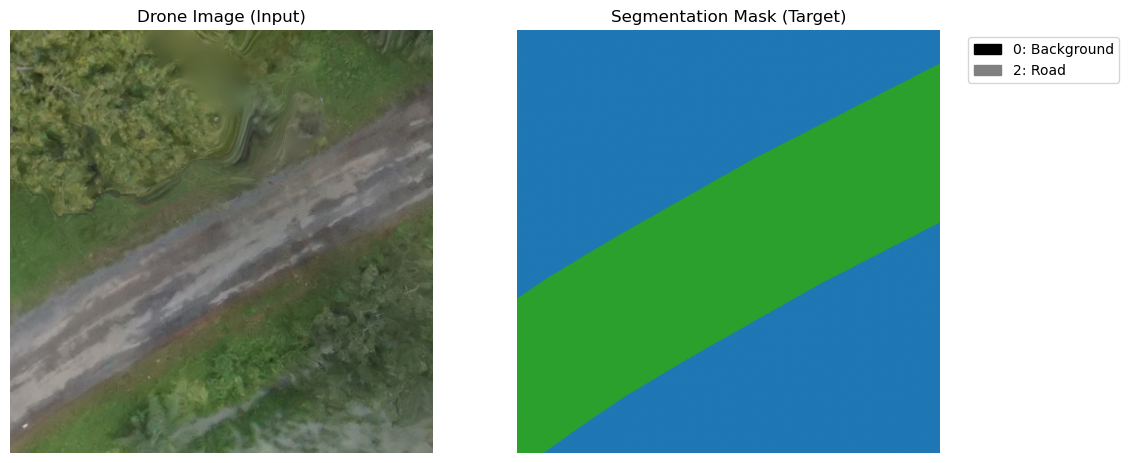

In [21]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as mpatches

# ============================
# CONFIGURATION
# ============================
# Path where we just saved the masks
MASK_DIR = os.path.join(os.getcwd(), "processed_tiles", "masks", "chhattisgarh")
IMG_DIR = os.path.join(os.getcwd(), "processed_tiles", "images", "chhattisgarh")

# Define what the numbers mean (for the legend)
classes = {
    0: ("Background", "black"),
    1: ("Water", "blue"),
    2: ("Road", "gray"),
    3: ("Roof (RCC)", "red"),
    4: ("Roof (Tiled)", "orange"),
    5: ("Roof (Tin)", "cyan"),
    6: ("Roof (Other)", "purple"),
    7: ("Utility", "yellow")
}

# ============================
# VERIFICATION LOGIC
# ============================

# 1. Find files
mask_files = glob.glob(os.path.join(MASK_DIR, "*.png"))

if not mask_files:
    print("❌ No masks found! Check your folder path.")
else:
    # 2. Pick a random mask that ISN'T empty (to make sure we see features)
    print(f"🔍 Found {len(mask_files)} masks. Searching for a non-empty example...")
    
    found = False
    for _ in range(50): # Try 50 random files
        mask_path = random.choice(mask_files)
        mask_arr = np.array(Image.open(mask_path))
        
        # If it has more than just background (0), show it!
        unique_vals = np.unique(mask_arr)
        if len(unique_vals) > 1:
            found = True
            break
    
    if not found:
        print("⚠️ Checked 50 random masks and all were blank (only 0). This might mean your shapefiles didn't overlap correctly.")
    else:
        # 3. Load the matching Image
        filename = os.path.basename(mask_path).replace("_mask", "")
        img_path = os.path.join(IMG_DIR, filename)
        img_arr = np.array(Image.open(img_path))

        # 4. Print Statistics
        print(f"\n✅ Inspecting: {filename}")
        print(f"   Shape: {mask_arr.shape}")
        print(f"   Unique Pixel Values found: {unique_vals}")
        print("   (These numbers correspond to your classes!)")

        # 5. Plot Side-by-Side
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        
        # Original Photo
        ax[0].imshow(img_arr)
        ax[0].set_title("Drone Image (Input)")
        ax[0].axis('off')

        # Colorized Mask (We multiply by 30 just to make the low numbers visible to the eye)
        # Better yet, let's use a colormap
        cmap = plt.cm.get_cmap('tab10', 10) 
        im = ax[1].imshow(mask_arr, cmap=cmap, vmin=0, vmax=9)
        ax[1].set_title("Segmentation Mask (Target)")
        ax[1].axis('off')

        # Create Legend
        patches = [mpatches.Patch(color=classes[i][1], label=f"{i}: {classes[i][0]}") 
                   for i in unique_vals]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.show()